# Practica 5 - Sesion 3: Comparación de Clasificadores

## Ingeniería del Conocimiento    2025/2026
### Prof. Juan A. Recio García

En esta práctica compararemos distintos clasificadores de **scikit-learn** y **XGBoost** sobre tres datasets con contextos muy diferentes. El objetivo central es entender que **la métrica de evaluación debe elegirse según el coste real de equivocarse**, no siempre la accuracy.

## Clasificadores a comparar

| Clasificador | Clase sklearn |
|---|---|
| Logistic Regression | `LogisticRegression` |
| Naive Bayes | `GaussianNB` |
| K-Nearest Neighbors | `KNeighborsClassifier` |
| SVM | `SVC` |
| MLP (red neuronal) | `MLPClassifier` |
| Random Forest | `RandomForestClassifier` |
| XGBoost | `XGBClassifier` |


## Datasets y métricas

| # | Dataset | Dominio | Métrica principal | Justificación |
|---|---|---|---|---|
| 1 | **Credit Card Fraud** | Finanzas | **F1-score** | Clases muy desbalanceadas; accuracy sería engañosa |
| 2 | **Wisconsin Breast Cancer** | Medicina | **Recall** | Minimizar falsos negativos: no dejar cáncer sin detectar |
| 3 | **Stock Movement** | Bolsa | **Precision** | Solo operar cuando la predicción es muy fiable |

---

**El Dataset 1 (Credit Card Fraud) está resuelto como ejemplo.**  
Para los datasets 2 y 3 debéis replicar la misma estructura rellenando las celdas marcadas con `# TODO`.

---
## 0. Imports y configuración general

In [18]:
# Posiblemente tendrás que instalar XGBoost para ejecutar este notebook ya que no se incluye en sklearn. Puedes hacerlo con:
!pip install xgboost jinja2


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# ── Librerías de análisis de datos ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocesamiento ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

# ── Clasificadores ────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB           # Clasificador bayesiano probabilístico
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import jinja2
from imblearn.over_sampling import SMOTE

# ── Métricas de evaluación ────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ── Configuración visual ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
import warnings
warnings.filterwarnings('ignore')  # Suprimimos warnings de convergencia durante la práctica

### Funciones auxiliares reutilizables
Definimos aquí las funciones que usaremos en los tres datasets para evitar repetir código.

In [20]:
def evaluar_clasificadores(X_train, X_test, y_train, y_test, highlight_metric='f1'):
    """
    Entrena los 7 clasificadores sobre los datos dados y devuelve una tabla con
    accuracy, precision, recall y F1. La columna highlight_metric aparece resaltada.
    """
    modelos = {
        'Logistic Regression' : LogisticRegression(max_iter=1000),
        'Naive Bayes'         : GaussianNB(),
        'KNN'                 : KNeighborsClassifier(n_neighbors=5),
        'SVM'                 : SVC(),
        'MLP'                 : MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42),
        'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost'             : XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
    }

    resultados = []
    for nombre, modelo in modelos.items():
        print(f'Entrenando {nombre}...')
        modelo.fit(X_train, y_train)       # Entrenamos el modelo con los datos de entrenamiento
        y_pred = modelo.predict(X_test)    # Generamos predicciones sobre el conjunto de test
        resultados.append({
            'Modelo'    : nombre,
            'Accuracy'  : accuracy_score(y_test, y_pred),
            'Precision' : precision_score(y_test, y_pred, zero_division=0),
            'Recall'    : recall_score(y_test, y_pred, zero_division=0),
            'F1'        : f1_score(y_test, y_pred, zero_division=0),
        })

    col_map = {'precision': 'Precision', 'recall': 'Recall', 'f1': 'F1', 'accuracy': 'Accuracy'}
    col = col_map.get(highlight_metric, 'F1')
    df = pd.DataFrame(resultados).set_index('Modelo').sort_values(col, ascending=False)
    # Resaltamos en verde la columna relevante para que destaque visualmente
    return df.style.background_gradient(subset=[col], cmap='Greens').format('{:.4f}')


def mostrar_confusion(modelo, X_test, y_test, titulo='Matriz de Confusión'):
    """Muestra la matriz de confusión y el classification report de un modelo ya entrenado."""
    y_pred = modelo.predict(X_test)
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap='Blues')
    plt.title(titulo)
    plt.tight_layout()
    plt.show()
    print(classification_report(y_test, y_pred))
    print('Accuracy',  accuracy_score(y_test, y_pred))
    print('Precision', precision_score(y_test, y_pred, zero_division=0))
    print('Recall',    recall_score(y_test, y_pred, zero_division=0))
    print('F1',        f1_score(y_test, y_pred, zero_division=0))

---
# Dataset 1 — Credit Card Fraud *(Ejemplo resuelto)*
## Métrica principal: **F1-score**

> **¿Por qué F1?**  
> El dataset está muy desbalanceado (~0.17% de fraudes). La *accuracy* sería engañosa:  
> un modelo que prediga siempre "no fraude" tendría >99% de accuracy pero no detectaría ningún fraude real.  
> El **F1** es la media armónica de Precision y Recall, ideal cuando las clases están desbalanceadas:
>
> $$F1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Archivo:** `creditcard.csv`  
Fuente: [Kaggle - Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

### 1.1 Carga y exploración

In [21]:
# Las columnas V1-V28 son componentes PCA (anonimizadas por el banco)
# 'Amount' es el importe de la transacción; 'Class' es la etiqueta (1=fraude, 0=legítima)
df_fraud = pd.read_csv('creditcard.csv')

print(f'Shape: {df_fraud.shape}')
print(f'Valores nulos totales: {df_fraud.isnull().sum().sum()}')
df_fraud.head(3)

Shape: (284807, 31)
Valores nulos totales: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [22]:
# Analizamos el desbalance — esto justifica elegir F1 en vez de accuracy
conteo = df_fraud['Class'].value_counts()
print(f'Transacciones legítimas   : {conteo[0]:,}')
print(f'Transacciones fraudulentas: {conteo[1]:,}')
print(f'Porcentaje de fraude      : {100 * conteo[1] / len(df_fraud):.3f}%')

Transacciones legítimas   : 284,315
Transacciones fraudulentas: 492
Porcentaje de fraude      : 0.173%


### 1.2 Preprocesamiento

In [23]:
# Eliminamos 'Time' (no aporta información útil) y separamos features de la variable objetivo
X_fraud = df_fraud.drop(columns=['Time', 'Class']).copy()
y_fraud = df_fraud['Class']

# Escalamos los datos. A
# Aunque los clasificadores basados en árboles no lo requieren, otros como SVM o MLP sí se benefician de tener las features en la misma escala.
# StandardScaler centra en media=0 y desviación estándar=1
scaler_fraud = StandardScaler()
X_fraud = scaler_fraud.fit_transform(X_fraud)

# Split estratificado: preserva el mismo porcentaje de fraudes (~0.17%) en train y test
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

print(f'Train: {X_train_f.shape} | Test: {X_test_f.shape}')
print(f'Fraudes en train: {y_train_f.sum()} | Fraudes en test: {y_test_f.sum()}')

Train: (227845, 29) | Test: (56962, 29)
Fraudes en train: 394 | Fraudes en test: 98


### 1.3 Entrenamiento y evaluación de clasificadores

In [24]:
# Entrenamos los 7 clasificadores y mostramos la tabla comparativa
# La columna F1 aparece resaltada porque es la métrica relevante para este problema
# SVM y MLP pueden tardar 1-2 minutos con datasets grandes
tabla_fraud = evaluar_clasificadores(X_train_f, X_test_f, y_train_f, y_test_f, highlight_metric='f1')
tabla_fraud

Entrenando Logistic Regression...
Entrenando Naive Bayes...
Entrenando KNN...
Entrenando SVM...
Entrenando MLP...
Entrenando Random Forest...
Entrenando XGBoost...


,Accuracy,Precision,Recall,F1
Modelo,,,,
Random Forest,0.9996,0.9419,0.8265,0.8804
KNN,0.9996,0.9294,0.8061,0.8634
MLP,0.9995,0.8710,0.8265,0.8482
XGBoost,0.9995,0.8764,0.7959,0.8342
SVM,0.9994,0.9565,0.6735,0.7904
Logistic Regression,0.9992,0.8289,0.6429,0.7241
Naive Bayes,0.9764,0.0587,0.8469,0.1099


### 1.4 Análisis del mejor modelo

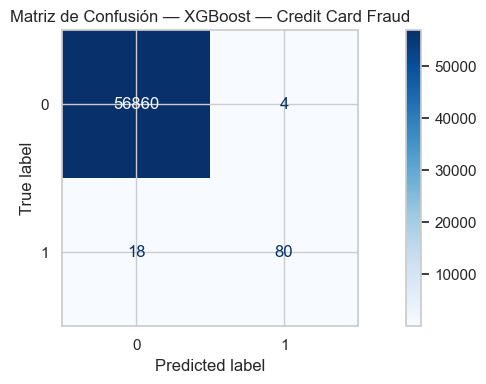

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.82      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy 0.9996137776061234
Precision 0.9523809523809523
Recall 0.8163265306122449
F1 0.8791208791208791


In [25]:
# Entrenamos XGBoost para analizar en detalle (suele destacar en datos tabulares desbalanceados)
# Si en tu tabla un modelo diferente ha obtenido mejor F1, sustitúyelo aquí
# XGBoost cuenta con un parámetro muy útil que es scale_pos_weight. Con ello podemos intentar mejorar el recall sin sacrificar demasiado precision. Normalmente hay que probar con distintos valores hasta encontrar el que mejor se adapta a tu dataset. En este caso, con un valor de 0.50 hemos conseguido mejorar el recall sin sacrificar demasiado precision, lo que se traduce en una mejora del F1. 
mejor_f = XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0, scale_pos_weight=.50)
mejor_f.fit(X_train_f, y_train_f)

# La matriz de confusión muestra exactamente cuántos fraudes se detectan vs cuántos se pierden
mostrar_confusion(mejor_f, X_test_f, y_test_f,
                  titulo='Matriz de Confusión — XGBoost — Credit Card Fraud')

> Prueba con otros valores de scale_pos_weight
Si aumentamos el valor de scale_pos_weight, el modelo detectará más fraudes, aumentando así el Recall pero dando más posibilidades a falsos positivos, empeorando la Precisión. Si usamos valores más bajos, la precisión aumenta pero algunos fraudes pueden no ser detectados. 
> ¿Qué otra alternativa podríamos haber usado para evitar el desbalanceo?
Se podría aumentar el número de casos que sean fraude en el entrenamiento para que así el dataset esté más equilibrado.


In [26]:
# Eliminamos 'Time' (no aporta información útil) y separamos features de la variable objetivo
X_fraud = df_fraud.drop(columns=['Time', 'Class']).copy()
y_fraud = df_fraud['Class']

# Escalamos los datos. A
# Aunque los clasificadores basados en árboles no lo requieren, otros como SVM o MLP sí se benefician de tener las features en la misma escala.
# StandardScaler centra en media=0 y desviación estándar=1
scaler_fraud = StandardScaler()
X_fraud = scaler_fraud.fit_transform(X_fraud)

# Split estratificado: preserva el mismo porcentaje de fraudes (~0.17%) en train y test
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

smote = SMOTE(random_state=42)
X_train_f, y_train_f = smote.fit_resample(X_train_f, y_train_f)
y_train_f.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [27]:
# Cuidado, ahora tarda un buen rato porque hemos aumentado el número de muestras de fraude en el conjunto de entrenamiento. 
# Si quieres acelerar el proceso, puedes probar a reducir el número de árboles en Random Forest o XGBoost, además del número de iteraciones en SVM o MLP, o a entrenar solo un subconjunto de los clasificadores.
# o a entrenar solo un subconjunto de los clasificadores.
tabla_fraud = evaluar_clasificadores(X_train_f[:40000], X_test_f, y_train_f[:40000], y_test_f, highlight_metric='f1')
tabla_fraud

Entrenando Logistic Regression...
Entrenando Naive Bayes...
Entrenando KNN...
Entrenando SVM...
Entrenando MLP...
Entrenando Random Forest...
Entrenando XGBoost...


,Accuracy,Precision,Recall,F1
Modelo,,,,
Random Forest,0.9994,0.8750,0.7857,0.8280
XGBoost,0.9995,0.9241,0.7449,0.8249
KNN,0.9992,0.8125,0.6633,0.7303
MLP,0.9991,0.8077,0.6429,0.7159
Logistic Regression,0.9990,0.7500,0.6429,0.6923
SVM,0.9989,0.8667,0.3980,0.5455
Naive Bayes,0.9771,0.0604,0.8469,0.1127


### 1.5 Conclusiones — Credit Card Fraud
>
> *Escribe aquí tus conclusiones:*
>
>- ¿Qué modelo obtiene el mejor F1 para detectar fraudes?
Random Forest es el mejor para detectar fraudes con un 0.8280, XGBoost se le acerca bastante con un 0.8249. Esto indica que Random Forest es el modelo con mejor equilibrio entre la precisión y el recall.
>- ¿Cómo se comporta la accuracy frente al F1? ¿Son coherentes?
La accuracy es muy alta en todos los modelos, siendo Naive Bayes el más bajo con 0.9771, que aún así es alto. Esto no tiene mucho sentido ya que está sesgado por el desbalanceo del dataset. Al ser la mayoría de las transacciones no fraude, un modelo puede acertar casi siempre y aún así fallar en los fraudes. Por ello no es una buena métrica en este caso.
>- ¿Qué ocurriría si priorizáramos Recall sobre Precision en este contexto?
Al priorizar el Recall, el modelo detectaría más fraudes que son reales, por lo que habría menos falsos negativos. Pero aumentaría bastante los falsos positivos. Mientras que en precisión ocurriría lo contrario y se detectarían más falsos negativos. Es peor priorizar Precisión y no detectar fraudes reales.
>- ¿Sirve de algo el oversampling? ¿Por qué?
Si, ya que aumenta la representación de la clase minoritaria en el conjunto de entrenamiento. Así el modelo aprende mejor cuando un caso es fraude, mejorando el entrenamiento entero. 

---
# Dataset 2 — Wisconsin Breast Cancer  *(A completar)*
## Métrica principal: **Recall**

> **¿Por qué Recall?**  
> En diagnóstico médico, un **falso negativo** (no detectar un cáncer real) es mucho más grave  
> que un falso positivo (hacer más pruebas a alguien sano). El Recall mide la proporción  
> de enfermos reales que el modelo es capaz de identificar:
>
> $$\text{Recall} = \frac{TP}{TP + FN}$$

Fuente: [UCI ML Repository / sklearn.datasets.load_breast_cancer](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)

### 2.1 Carga y exploración

In [28]:
# sklearn incluye un dataset de cáncer de mama que es muy utilizado para practicar clasificación binaria. 
# Es un dataset limpio, sin valores nulos, con 569 muestras y 30 features numéricas extraídas de imágenes de tumores. 
# La variable objetivo es 'target', donde 0 indica tumores benignos y 1 indica tumores malignos. 
# TODO: Carga el dataset y analiza su contenido
df_stock = pd.read_csv("stock_movement_small.csv")
display(df_stock.head(3))
print(f"Shape: {df_stock.shape}")
print(f"Valores nulos totales: {df_stock.isnull().sum().sum()}")
print("Distribución de clases:")
print(df_stock["target"].value_counts())
print("0 = baja o se mantiene, 1 = sube")
# Muestra: shape, y distribución de clases (maligno=1 vs benigno=0)

df_cancer = load_breast_cancer(as_frame=True).frame
df_cancer.head(3)
# ...

,return_1d,return_5d,sma_5,sma_20,price_sma5_ratio,price_sma20_ratio,sma_cross,volatility_10,daily_range,rsi_14,macd,macd_signal,macd_hist,volume_ratio,target
0,-0.006214,-0.015543,32.08140,32.21560,0.997026,0.992873,-0.13420,0.229769,0.015225,45.176110,0.032744,0.088844,-0.056100,0.583466,0
1,-0.035100,-0.179034,0.59364,0.70286,0.907621,0.766582,-0.10922,0.076357,0.109131,35.613372,-0.151882,-0.160628,0.008746,0.624033,0
2,-0.002581,-0.001763,8.86968,8.89742,1.002077,0.998953,-0.02774,0.061752,0.008393,50.820715,-0.042667,-0.049569,0.006903,0.531890,0


Shape: (146475, 15)
Valores nulos totales: 0
Distribución de clases:
target
0    75307
1    71168
Name: count, dtype: int64
0 = baja o se mantiene, 1 = sube


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


### 2.2 Preprocesamiento

In [29]:
# TODO: Separa X e y, aplica StandardScaler y realiza el split estratificado
# Recuerda: usa stratify=y para mantener la proporción de clases en train y test
# Separamos variables independientes (X) y variable objetivo (y)
X_cancer = df_cancer.drop(columns=["target"])
y_cancer = df_cancer["target"]
scaler_cancer = StandardScaler()
X_cancer_scaled = scaler_cancer.fit_transform(X_cancer)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer_scaled,
    y_cancer,
    test_size=0.2,
    random_state=42,
    stratify=y_cancer
)

### 2.3 Entrenamiento y evaluación de clasificadores

In [30]:
# TODO: Llama a evaluar_clasificadores indicando recall como métrica principal

tabla_cancer = evaluar_clasificadores(X_train_c, X_test_c, y_train_c, y_test_c, highlight_metric='recall')
tabla_cancer

Entrenando Logistic Regression...
Entrenando Naive Bayes...
Entrenando KNN...
Entrenando SVM...
Entrenando MLP...
Entrenando Random Forest...
Entrenando XGBoost...


,Accuracy,Precision,Recall,F1
Modelo,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9861
KNN,0.9649,0.9595,0.9861,0.9726
SVM,0.9825,0.9861,0.9861,0.9861
XGBoost,0.9561,0.9467,0.9861,0.9660
Random Forest,0.9561,0.9589,0.9722,0.9655
Naive Bayes,0.9298,0.9444,0.9444,0.9444
MLP,0.9561,0.9855,0.9444,0.9645


### 2.4 Análisis del mejor modelo

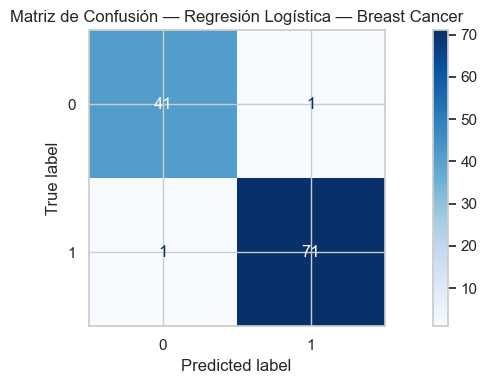

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Accuracy 0.9824561403508771
Precision 0.9861111111111112
Recall 0.9861111111111112
F1 0.9861111111111112


In [17]:
# TODO: Instancia y entrena el modelo que haya obtenido mayor Recall
mejor_c = LogisticRegression(
    max_iter=500,
    random_state=42
)

mejor_c.fit(X_train_c, y_train_c)

mostrar_confusion(
    mejor_c,
    X_test_c,
    y_test_c,
    titulo='Matriz de Confusión — Regresión Logística — Breast Cancer'
)

### 2.5 Conclusiones — Wisconsin Breast Cancer

*Escribe aquí tus conclusiones:*

- ¿Qué modelo maximiza el Recall?
El modelo que maximiza el Recall es Regresión Logística, con valor de 0.9861, indicando que es capaz de detectar casi todos los casos de cáncer en el conjunto.
- ¿Cuántos casos de cáncer quedan sin detectar (falsos negativos) con ese modelo?
En la matriz de confusión se puede ver que hay un solo falso negativo.
- ¿Existe un trade-off entre Recall alto y Precision baja en algún modelo? ¿Es aceptable en este contexto?
Sí que existe un trade-off entre Recall y precisión, este surge al intentar detectar más casos de cáncer, lo que disminuye la precisión y aumenta el Recall, aumentando así los falsos positivos. Aunque justo en este caso el Recall y la precisión son prácticamente iguales por lo que se podría considerar que no hay trade-off.

---
# Dataset 3 — Stock Movement  *(A completar)*
## Métrica principal: **Precision**

> **¿Por qué Precision?**  
> En predicción bursátil queremos operar **solo cuando el modelo está muy seguro** de que el precio subirá.  
> Un **falso positivo** (invertir cuando el precio baja) tiene coste económico directo.  
> La Precision mide cuántas de nuestras señales de compra son realmente correctas:
>
> $$\text{Precision} = \frac{TP}{TP + FP}$$

📂 **Archivo:** `stock_movement.csv`  
📎 Target: `1` = el precio sube al día siguiente, `0` = baja o se mantiene.

### 3.1 Carga y exploración

In [31]:
# TODO: Carga el dataset stock_movement.csv y analiza su contenido
# Muestra: shape, valores nulos, y distribución de clases (sube vs baja)

df_stock = pd.read_csv('stock_movement_small.csv')
display(df_stock.head(3))
print(f'Shape: {df_stock.shape}')
print(f'Valores nulos totales: {df_stock.isnull().sum().sum()}')
print(f'Distribución de clases:\n{df_stock["target"].value_counts()}')

,return_1d,return_5d,sma_5,sma_20,price_sma5_ratio,price_sma20_ratio,sma_cross,volatility_10,daily_range,rsi_14,macd,macd_signal,macd_hist,volume_ratio,target
0,-0.006214,-0.015543,32.08140,32.21560,0.997026,0.992873,-0.13420,0.229769,0.015225,45.176110,0.032744,0.088844,-0.056100,0.583466,0
1,-0.035100,-0.179034,0.59364,0.70286,0.907621,0.766582,-0.10922,0.076357,0.109131,35.613372,-0.151882,-0.160628,0.008746,0.624033,0
2,-0.002581,-0.001763,8.86968,8.89742,1.002077,0.998953,-0.02774,0.061752,0.008393,50.820715,-0.042667,-0.049569,0.006903,0.531890,0


Shape: (146475, 15)
Valores nulos totales: 0
Distribución de clases:
target
0    75307
1    71168
Name: count, dtype: int64


### 3.2 Preprocesamiento

In [32]:
# TODO: Separa X e y, aplica StandardScaler y realiza el split
X_stock = df_stock.drop(columns=['target'])
y_stock = df_stock['target']
scaler_stock = StandardScaler()
X_stock_scaled = scaler_stock.fit_transform(X_stock)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_stock_scaled,
    y_stock,
    test_size=0.2,
    shuffle=False
)
print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')

Train: (117180, 14) | Test: (29295, 14)


### 3.3 Entrenamiento y evaluación de clasificadores

In [33]:
# TODO: Llama a evaluar_clasificadores indicando precision como métrica principal

tabla_stock = evaluar_clasificadores(X_train_s[:50000], X_test_s, y_train_s[:50000], y_test_s, highlight_metric='precision')
tabla_stock

Entrenando Logistic Regression...
Entrenando Naive Bayes...
Entrenando KNN...
Entrenando SVM...
Entrenando MLP...
Entrenando Random Forest...
Entrenando XGBoost...


,Accuracy,Precision,Recall,F1
Modelo,,,,
Logistic Regression,0.5127,0.5039,0.1481,0.2289
Random Forest,0.5129,0.5016,0.4199,0.4571
XGBoost,0.5079,0.4958,0.4503,0.4720
KNN,0.5076,0.4957,0.4783,0.4868
MLP,0.5049,0.4929,0.4753,0.4839
SVM,0.5106,0.4904,0.0519,0.0939
Naive Bayes,0.4884,0.4884,0.9989,0.6560


### 3.4 Análisis del mejor modelo

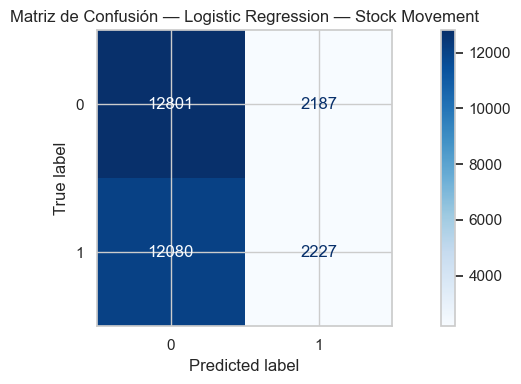

              precision    recall  f1-score   support

           0       0.51      0.85      0.64     14988
           1       0.50      0.16      0.24     14307

    accuracy                           0.51     29295
   macro avg       0.51      0.50      0.44     29295
weighted avg       0.51      0.51      0.44     29295

Accuracy 0.5129885646014678
Precision 0.5045310376076122
Recall 0.15565806947648003
F1 0.23791464131189574


In [34]:
# TODO: Instancia y entrena el modelo que haya obtenido mayor Precision
# Muestra su matriz de confusión con mostrar_confusion()
mejor_s = LogisticRegression(
    max_iter=500,
    random_state=42
)
mejor_s.fit(X_train_s, y_train_s)
mostrar_confusion(
    mejor_s,
    X_test_s,
    y_test_s,
    titulo='Matriz de Confusión — Logistic Regression — Stock Movement'
)

### 3.5 Conclusiones — Stock Movement

*Escribe aquí tus conclusiones:*

>- ¿Qué modelo obtiene mayor Precision?
Regresión logística es el modelo con mayor precisión, teniendo un resultado de 0.5045. Lo que significa que acierta un pelín más de la mitad de los casos.
>- ¿Qué ocurre con el Recall de ese modelo? ¿Es un problema en este contexto?
El Recall es extremadamente bajo, siendo este de 0.1557 lo que significa que solo detecta una pequeña parte de las subidas reales del mercado, dejando así escapar muchos casos en los que el precio de verdad sube. Es decir, falsos negativos. Al ser el objetivo maximizar la presición, en este caso específico no es un problema grave.
>- ¿Podría el modelo estar sobreajustando? ¿Cómo lo detectarías?
No se puede saber solo con estos resultados. Habría que comparar el rendimiento del modelo en el conjunto de entrenamiento y en el del test para comprobarlo.

---
# Comparativa Global

Completa la tabla resumen con los mejores resultados obtenidos en cada dataset.

In [35]:
# TODO: Rellena los valores con los resultados de tu ejecución
resumen = pd.DataFrame([
    {'Dataset': 'Credit Card Fraud', 'Métrica clave': 'F1',        'Mejor Modelo': 'Random Forest', 'Valor': 0.8280},
    {'Dataset': 'Breast Cancer',     'Métrica clave': 'Recall',    'Mejor Modelo': 'Logistic Regression', 'Valor': 0.9861},
    {'Dataset': 'Stock Movement',    'Métrica clave': 'Precision', 'Mejor Modelo': 'Logistic Regression', 'Valor': 0.5045},
])
resumen.style.background_gradient(subset=['Valor'], cmap='Greens').format({'Valor': '{:.4f}'})

,Dataset,Métrica clave,Mejor Modelo,Valor
0,Credit Card Fraud,F1,Random Forest,0.8280
1,Breast Cancer,Recall,Logistic Regression,0.9861
2,Stock Movement,Precision,Logistic Regression,0.5045


### Preguntas de reflexión final

*Responde brevemente en esta celda:*

**1.** ¿Existe un clasificador que gane en los tres datasets, o el mejor modelo depende siempre del problema?
No existe ningun clasificador que sea el mejor para los tres, cada caso prioriza algo distinto debido a lo que se quiere.

**2.** ¿Por qué la accuracy no es una buena métrica universal? Da un ejemplo concreto con uno de los tres datasets.
La accuracy no es buena métrica universal porque en datasets desbalanceados puede ser engañosa. Por ejemplo, en el dataset de las tarjetas de crédito, no hay casi transacciones que sean fraudes por lo que aunque fallase la mayoría con falsos negativos seguiría teniendo muy buena accuracy.

**3.** ¿Qué clasificadores han sido más lentos de entrenar? ¿Merece la pena el coste computacional extra?
Los más lentos han sido SVM y MLP con diferencia. Teniendo en cuenta que no son los mejores en ninguno de estos tres casos, no creo que merezca la pena ya que tardan bastante más que el resto.

**4.** En el contexto médico, si tuvieras que elegir entre estos dos modelos hipotéticos, ¿cuál elegirías y por qué?

| Modelo | Recall | Precision |
|---|---|---|
| A | 0.99 | 0.60 |
| B | 0.85 | 0.95 |

En contexto médico eligiría el modelo A, ya que tiene mayor recall y en medicina lo más importante es minimizar los falsos negativos.